# **Data Scraping Project**

By: Fernando Cortés Rentería

The goal of the following code is to manage the data from various different sources and to use the resulting
data model to answer the question: "does this house need a roof change?"

## Initial Data Loading

### Downloading libraries and configuring Pandas

In [1]:
import pandas as pd

# I import and configure pandas display options
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.width', 120)          # Wider output
pd.set_option("display.precision", 2)
pd.set_option('display.float_format', '{:,.2f}'.format)

### Creating Florida Dataset from Broward and Miami-Dade County Parcel info

In [2]:
broward = pd.read_csv('broward_parcels.csv')
miami = pd.read_csv('miamidade_parcels.csv')

In [3]:
# i add county identifier
miami['county'] = 'Miami-Dade'
broward['county'] = 'Broward'

In [4]:
# merge into a single dataframe
florida_df = pd.concat([broward, miami], ignore_index=True)
florida_df.rename(columns={'parcel_id': 'ParcelID'}, inplace=True)

In [5]:
'''filter for residential properties (DOR_UC codes 1-4):
    1 - Single Family Residential
    2 - Mobile Home
    3 - Condominium
    4 - Cooperative'''


florida_residential = florida_df[florida_df['property_use'] <= 4]

### Pre-cleaning Roof Permit Datasets

#### Tamarac

In [ ]:
tamarac_permits = pd.read_csv('./permits/permits_tamarac.csv')
tamarac_permits["Applied Date"] = pd.to_datetime(tamarac_permits["Applied Date"], format='mixed')

#### Pompano

In [ ]:
# pompano permits
pompano_permits = pd.read_json('./permits/permits_pompano.json')
pompano_permits['Applied Date'] = pd.to_datetime(pompano_permits['application_date'], format='mixed')

pompano_permits['parcel_id'] = pompano_permits['parcel_id'].str.replace('-','')

pompano_cleaned = pompano_permits.rename(columns={
    'parcel_id': 'ParcelID',
    'application_status': 'Status',
    'application_type': 'WorkType',
    'general_contractor': 'Contractor'
})[['ParcelID', 'WorkType', 'Contractor', 'Status', 'Applied Date']]

pompano_cleaned['Contractor'].fillna('Unknown', inplace=True)

In [8]:
pompano_cleaned

,ParcelID,WorkType,Contractor,Status,Applied Date
0,920501217001133,B-*ROOF RE-ROOF,M & L ROOFING & CONSTRUCTION,CLOSED,1999-12-29
1,83311773000541,B-*ROOF RE-ROOF,SOLAR SHIELD URETHANE ROOF SYS,CLOSED,1999-12-29
2,832905119003202,B-*ROOF RE-ROOF,A B C ROOFING CORP,CLOSED,1999-12-27
3,8330135001600,B-*ROOF RE-ROOF,EVANS BROTHERS ROOFING INC,CLOSED,1999-12-27
4,823623EFFLUE001799,B-ADDC ADD NON-RESIDENTIAL,R J SULLIVAN CORPORATION,OPEN PERMITS,1999-12-23
...,...,...,...,...,...
994,822609712002100,B-*ROOF RE-ROOF,LEWIS ROOFING,CLOSED,1998-06-23
995,920131G37000191,B-*ROOF RE-ROOF,HURRICANE ROOFING CORP,CLOSED,1998-06-23
996,92020018807T800063118,B-A+AM ADD + ALT MULTI FAM,M P L CONSTRUCTION INC,CERTIFICATE ISSUED,1998-06-22
997,822807PARCEL003201,B-*ROOF RE-ROOF,ROOFING SYSTEMS INC OF PBC,CLOSED,1998-06-19


#### Hallandale Beach

In [ ]:
hallandale_beach_permits = pd.read_csv('./permits/permits_hallandale_beach.csv')
hallandale_cleaned = hallandale_beach_permits.rename(columns={
    'Main Parcel': 'ParcelID',
    'Type': 'WorkType',
    'Company Name': 'Contractor'
})[['ParcelID', 'WorkType', 'Contractor', 'Status', 'Applied Date']]
hallandale_cleaned['Applied Date'] = pd.to_datetime(hallandale_cleaned['Applied Date'], format='%m/%d/%Y')
hallandale_cleaned['Contractor'].fillna('Unknown', inplace=True)

#### Hurricanes DataFrame

In [10]:
hurricanes = pd.read_csv('hurricanes_fl.csv')
hurricanes['Date of Impact'] = hurricanes['Date of Impact'].astype(str) + ' ' + hurricanes['Year'].astype(str)
hurricanes['Date of Impact'] = pd.to_datetime(hurricanes['Date of Impact'])

### Joining Datasets

#### Permits

In [11]:
permits = pd.concat([tamarac_permits, hallandale_cleaned, pompano_cleaned], ignore_index=True)

In [12]:
permits

,ParcelID,WorkType,Contractor,Status,Applied Date
0,494111100371,REROOF SHINGLES,A & A ROOFING CONTRACTORS INC,CLOSED,2017-06-01
1,494104670224,REROOF SHINGLES ONLY,A & J ROOFING CORP,CLOSED,2016-02-03
2,494103050230,SEE 19-242 REROOF FLAT,A & J ROOFING CORP,DUPLICATE,2019-01-16
3,494103050230,REROOF FLAT,A & J ROOFING CORP,CLOSED,2019-01-16
4,494113100880,RE-ROOF SHINGLE & FLAT,A & J ROOFING CORP,APPROVED,2022-04-11
...,...,...,...,...,...
2993,822609712002100,B-*ROOF RE-ROOF,LEWIS ROOFING,CLOSED,1998-06-23
2994,920131G37000191,B-*ROOF RE-ROOF,HURRICANE ROOFING CORP,CLOSED,1998-06-23
2995,92020018807T800063118,B-A+AM ADD + ALT MULTI FAM,M P L CONSTRUCTION INC,CERTIFICATE ISSUED,1998-06-22
2996,822807PARCEL003201,B-*ROOF RE-ROOF,ROOFING SYSTEMS INC OF PBC,CLOSED,1998-06-19


In [13]:
permits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2998 entries, 0 to 2997
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ParcelID      2992 non-null   object        
 1   WorkType      2945 non-null   object        
 2   Contractor    2998 non-null   object        
 3   Status        2998 non-null   object        
 4   Applied Date  2998 non-null   datetime64[ns]
dtypes: datetime64[ns](1), object(4)
memory usage: 117.2+ KB


#### Main df creation

In [14]:
df = pd.merge(permits, florida_residential, left_on='ParcelID', right_on='ParcelID', how='inner')

-----
## Main Data Pre-Processing

### Visualizing Data

In [15]:
df.head(5)

,ParcelID,WorkType,Contractor,Status,Applied Date,situs_address,year_built,county_code,property_use,lot_size,building_area,land_value,just_value,county
0,494111100371,REROOF SHINGLES,A & A ROOFING CONTRACTORS INC,CLOSED,2017-06-01,"6195 LAUREL LN ##B, TAMARAC 33319",1981,16,1,2385,2378,"9,540.00","381,120.00",Broward
1,494104670224,REROOF SHINGLES ONLY,A & J ROOFING CORP,CLOSED,2016-02-03,"7182 WOODMONT WAY, TAMARAC 33321",1990,16,1,2298,1708,"34,470.00","407,000.00",Broward
2,494113100880,RE-ROOF SHINGLE & FLAT,A & J ROOFING CORP,APPROVED,2022-04-11,"4907 NW 55 ST, TAMARAC 33319",1969,16,1,4173,1078,"12,520.00","257,470.00",Broward
3,494104AB0210,REROOF FLAT ONLY,A & M FOX ROOFING,CLOSED,2014-06-05,"7808 BEECHFERN CIR #21, TAMARAC 33321",1980,16,4,3345,1684,0.00,"366,720.00",Broward
4,494106012240,REROOF TILE AND FLAT,A & M FOX ROOFING,CLOSED,2014-10-24,"7000 NW 103 AVE, TAMARAC 33321",1979,16,1,10035,2086,"50,150.00","445,640.00",Broward


### Normalization and Encoding

In [16]:
pd.set_option('display.max_rows', 20)
df['WorkType'].value_counts()

WorkType
BD Roofing - Res - Replace                    296
Building Roofing - Combo                       62
BD Roofing - Com - Replace                     58
REROOF SHINGLE AND FLAT                        38
Building Roofing - Shingle                     30
                                             ... 
Local Business Tax Receipt - Professionals      1
Local Business Tax Receipt                      1
Certificate of Use                              1
CAVALIER                                        1
VALENTINE/REROOF                                1
Name: count, Length: 524, dtype: int64

In [17]:
def normalize_material(work_type: str) -> str:
    # Handle missing or non-string values
    if not isinstance(work_type, str):
        return "Other/Unknown"
    
    wt = work_type.upper()

    # Check for shingles
    has_shingle = "SHINGLE" in wt or "SHINGLES" in wt
    # Check for tile
    has_tile = "TILE" in wt or "TILES" in wt
    # Check for flat
    has_flat = "FLAT" in wt
    # Check for metal
    has_metal = "METAL" in wt

    # Assign categories
    if has_shingle and has_tile:
        return "Shingle + Tile"
    elif has_shingle and has_flat:
        return "Shingle + Flat"
    elif has_tile and has_flat:
        return "Tile + Flat"
    elif has_shingle:
        return "Shingle"
    elif has_tile:
        return "Tile"
    elif has_flat:
        return "Flat"
    elif has_metal:
        return "Metal"
    else:
        return "Other/Unknown"

df['Roof_Material'] = df['WorkType'].apply(normalize_material)
df['Roof_Material'].value_counts()

Roof_Material
Other/Unknown     848
Shingle           142
Shingle + Flat    111
Tile              110
Flat               98
Tile + Flat        74
Shingle + Tile      5
Metal               3
Name: count, dtype: int64

### Feature Engineering

New variables:

Integers:
* 'Time Since Last Permit': Counts the amount of days that a parcel has had the same roof without any new permits.

Booleans:
* 'multiple_re_roofs': Identifies duplicated parcel IDs, which signal a house requiring a roof repair or a re-roofing more than once.
* 'too_close': Identifies permits taken within 0 or 1 days of each other for the same parcel, likely due to bureacracy.
* 'after_hurricane': Identifies permits that were taken up to 6 months after a hurricane that affected Florida.
* *'needs_roof_change'*: The primary dependent variable that needs to be predicted. Marks any house that has needed a roof change in the past.


In [18]:
# idenntify the parcels with multiple permits
duplicated_permits = df["ParcelID"].value_counts()[df["ParcelID"].value_counts() > 1]

df['multiple_re_roofs'] = df.groupby("ParcelID")["ParcelID"].transform("count") > 1

df = df.sort_values(by='Applied Date')
df['Time Since Last Permit'] = df.groupby('ParcelID')['Applied Date'].diff().dt.days

df = df[df['year_built'] != 0]

# Convert year_built into a datetime (Jan 1 of that year)
df["year_built"] = pd.to_datetime(df["year_built"].astype(str), format="%Y")

# Compute difference in days between Applied Date and built_date
fill_values = (df["Applied Date"] - df["year_built"]).dt.days

# Fill NaNs in 'Time Since Last Permit' with this difference
df["Time Since Last Permit"] = df["Time Since Last Permit"].fillna(fill_values)

train_df = df[df['multiple_re_roofs'] == True]



In [19]:
avg_time = train_df.loc[train_df['Time Since Last Permit'].notna() & (train_df['Time Since Last Permit'] != 0),
                        'Time Since Last Permit'].mean()

print(f"Average time since last permit (days): {avg_time:.2f}")

Average time since last permit (days): 8916.59


In [20]:
# Defining my primary boolean indicator:

df['too_close'] = df['Time Since Last Permit'].notna() & (df['Time Since Last Permit'] <= 1)


df["needs_roof_change"] = False
mask = df["ParcelID"].duplicated(keep="last") & ~df["too_close"]
df.loc[mask, "needs_roof_change"] = True

In [21]:
df['needs_roof_change'].value_counts()

needs_roof_change
False    1223
True      156
Name: count, dtype: int64

In [22]:
df["after_hurricane"] = df["Applied Date"].apply(
    lambda d: any((abs((d - h_date).days) <= 180) for h_date in hurricanes["Date of Impact"])
)

## Initial Data Analysis

### Graphing Relevant Variables

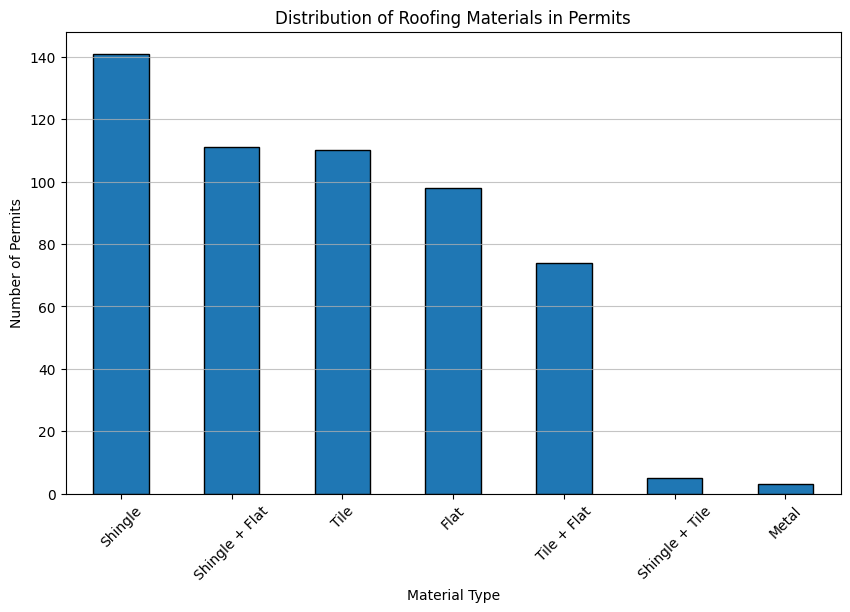

In [23]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Count normalized categories
material_counts = df["Roof_Material"][df['Roof_Material'] != 'Other/Unknown'].value_counts()

# Plot
plt.figure(figsize=(10,6))
material_counts.plot(kind="bar", edgecolor="black")
plt.title("Distribution of Roofing Materials in Permits")
plt.xlabel("Material Type")
plt.ylabel("Number of Permits")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.75)
plt.show()


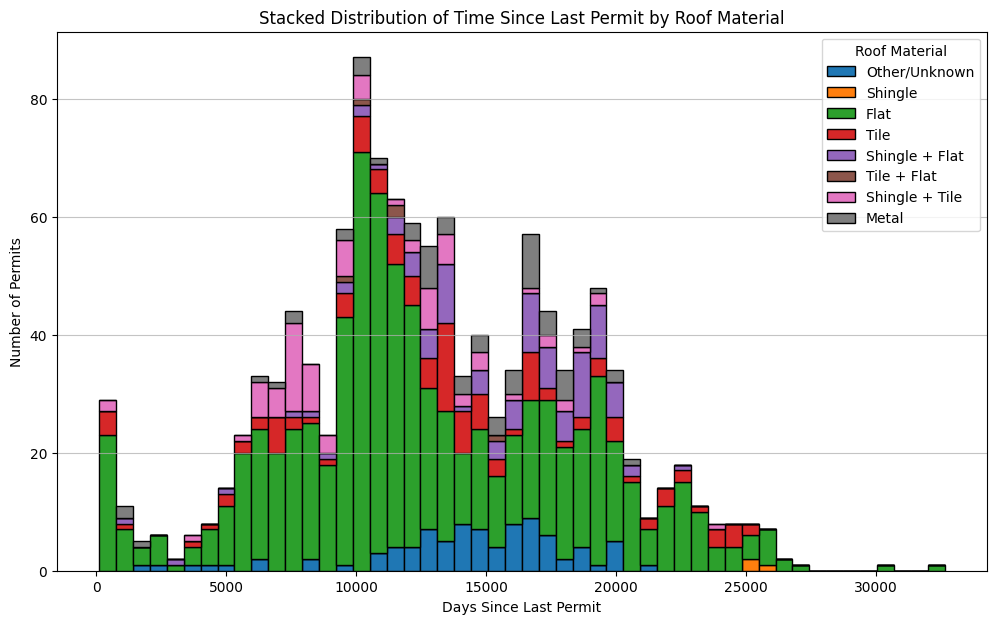

In [24]:
# Filter out NaN and 0 values
data = df[
    df["Time Since Last Permit"].notna() &
    (df["Time Since Last Permit"] > 90)
]

# Prepare the data grouped by roof material
grouped = [
    group["Time Since Last Permit"].values
    for _, group in data.groupby("Roof_Material")
]

labels = data["Roof_Material"].unique()

# Plot stacked histogram
plt.figure(figsize=(12, 7))
plt.hist(grouped, bins=50, stacked=True, label=labels, edgecolor="black")

plt.title("Stacked Distribution of Time Since Last Permit by Roof Material")
plt.xlabel("Days Since Last Permit")
plt.ylabel("Number of Permits")
plt.legend(title="Roof Material")
plt.grid(axis="y", alpha=0.75)
plt.show()

array([[<Axes: title={'center': 'Applied Date'}>,
        <Axes: title={'center': 'Time Since Last Permit'}>],
       [<Axes: title={'center': 'year_built'}>, <Axes: >]], dtype=object)

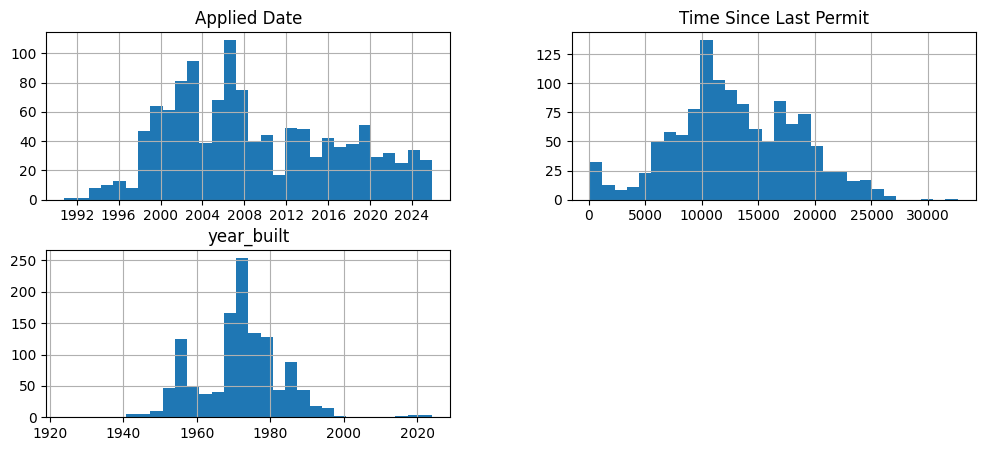

In [25]:
data[['Applied Date', 'Time Since Last Permit', 'year_built']].hist(figsize=(12, 5), bins=30)

### Descriptive Statistics

In [26]:
df.describe()

,Applied Date,year_built,county_code,property_use,lot_size,building_area,land_value,just_value,Time Since Last Permit
count,1379,1379,"1,379.00","1,379.00","1,379.00","1,379.00","1,379.00","1,379.00","1,379.00"
mean,2009-11-05 11:50:04.786076928,1973-07-04 06:12:47.512690352,16.00,1.18,"18,051.17","7,616.66","221,304.58","1,700,130.62","11,465.87"
min,1990-10-17 00:00:00,1924-01-01 00:00:00,16.00,1.00,0.00,550.00,0.00,"101,930.00","-10,434.00"
25%,2003-01-11 12:00:00,1968-01-01 00:00:00,16.00,1.00,"4,983.00","1,366.00","20,880.00","339,690.00","7,626.50"
50%,2008-03-05 00:00:00,1973-01-01 00:00:00,16.00,1.00,"6,593.00","1,688.00","33,750.00","416,470.00","11,658.00"
75%,2016-11-17 00:00:00,1980-01-01 00:00:00,16.00,1.00,"8,488.50","2,098.00","50,445.00","522,555.00","16,590.50"
max,2025-12-03 00:00:00,2024-01-01 00:00:00,16.00,4.00,"700,702.00","472,639.00","10,338,220.00","92,675,900.00","32,628.00"
std,NaN,NaN,0.00,0.66,"83,115.33","42,872.09","1,080,212.43","8,321,695.63","6,746.59"


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1379 entries, 1192 to 234
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ParcelID                1379 non-null   object        
 1   WorkType                1329 non-null   object        
 2   Contractor              1379 non-null   object        
 3   Status                  1379 non-null   object        
 4   Applied Date            1379 non-null   datetime64[ns]
 5   situs_address           1379 non-null   object        
 6   year_built              1379 non-null   datetime64[ns]
 7   county_code             1379 non-null   int64         
 8   property_use            1379 non-null   int64         
 9   lot_size                1379 non-null   int64         
 10  building_area           1379 non-null   int64         
 11  land_value              1379 non-null   float64       
 12  just_value              1379 non-null   float64    

## Data Processing

### Further encoding of Roof Materials

In [28]:
df["is_shingle"] = df["Roof_Material"].str.contains("Shingle")
df["is_tile"] = df["Roof_Material"].str.contains("Tile")
df["is_flat"] = df["Roof_Material"].str.contains("Flat")
df['is_metal'] = df["Roof_Material"].str.contains("Metal")
df['is_other'] = ~(df["is_shingle"] | df["is_tile"] | df["is_flat"] | df["is_metal"])

### Correlation Matrix of Predictive Variables

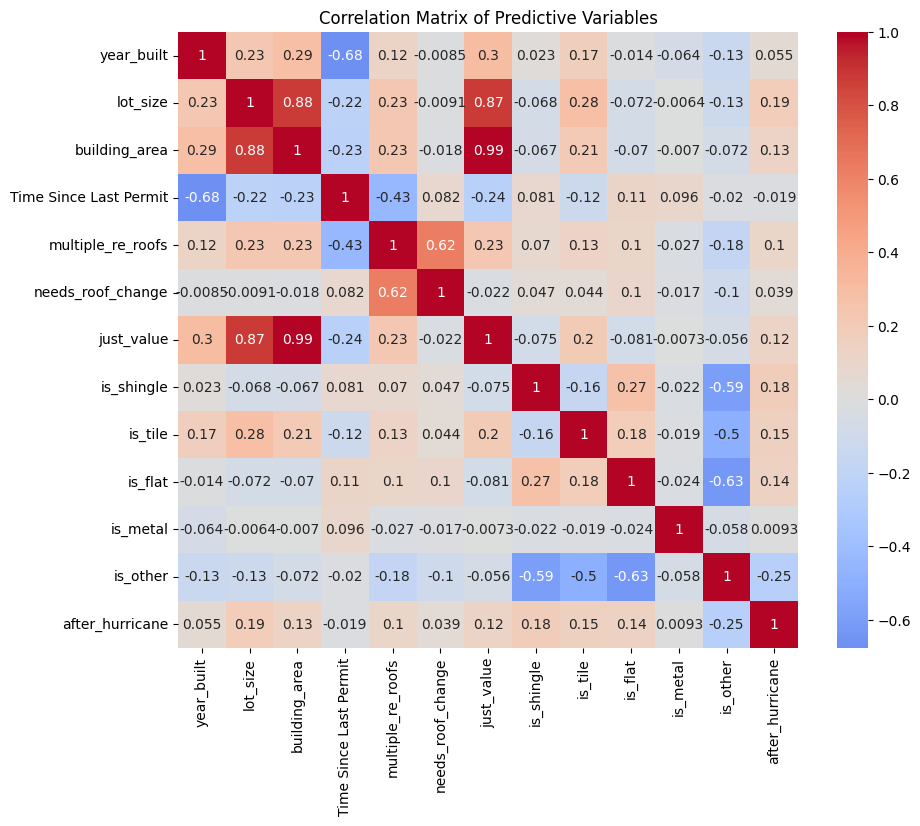

In [29]:
# Select numeric + boolean columns you want to test
candidate_cols = [
    "year_built",
    "lot_size",
    "building_area",
    "Time Since Last Permit",
    "multiple_re_roofs",
    "needs_roof_change",
    "just_value",
    "is_shingle",
    "is_tile",
    "is_flat",
    "is_metal",
    "is_other",
    "after_hurricane"
]

# Convert booleans to integers (True=1, False=0) for correlation
df_corr = df[candidate_cols].astype(int)

# Compute correlation matrix
corr_matrix = df_corr.corr()

# Optional: heatmap for visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Predictive Variables")
plt.show()


Correlations Analysis:
The only correlations strong enough to exclude variables from the model are in the following three:

* lot_size, building_area & just_value

For this reason, I'll only keep just_value in the final model

-----
## Data Splitting & Scaling

In [54]:
from sklearn.model_selection import train_test_split

# 20% testing data, 80% training data

# Extract the year as an integer
df['year'] = df['year_built'].dt.year.astype(int)

X = np.array(df[['year', 'Time Since Last Permit',
        'multiple_re_roofs', 'just_value', 'is_shingle', 'is_tile', 
        'is_flat', 'is_metal', 'is_other']].astype(int)) # Total variables: 9

y = np.array(df['needs_roof_change'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, 
    stratify=y
)

### Scaling the Data

In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
model = LogisticRegression()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
# Scaling the data
# numpy array since it's unnecessary to visualize data in table format

X_train_mean = np.mean(X_train, axis=0)
X_train_std = np.std(X_train, axis=0)

X_train_scaled = (X_train - X_train_mean) / X_train_std
X_test_scaled = (X_test - X_train_mean) / X_train_std

## Running the Models

### Important Metrics for classification Algorithms:

Accuracy = (TP + TN) / (TP + TN + FP + FN)

Precision = TP / (TP + FP)

Recall (TPR) = TP / (TP + FN)

F1_Score = (2 * Precision * Recall) / (Precision + Recall)

Fallout (FPR) = FP / (TP + FN)

### importing libraries

In [57]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif

### KNeighbors Classifier (KNN)

In [98]:
# initial run of the model
knn = KNeighborsClassifier()

# fitting the model to the data
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Fine tuning the model:

In [111]:
from sklearn.model_selection import GridSearchCV

param_grid = {"n_neighbors": range(1, 10)}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

print("Best k:", grid.best_params_)

Best k: {'n_neighbors': 2}


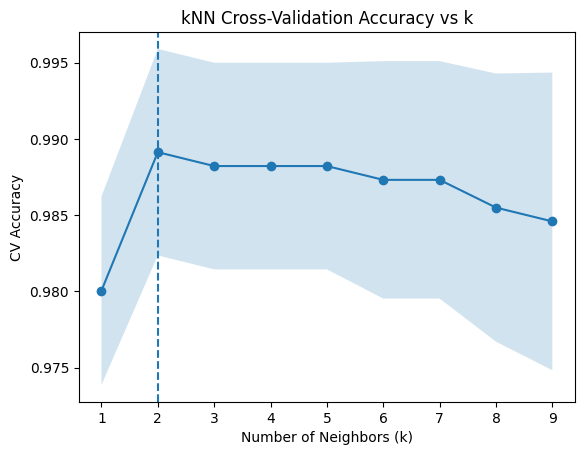

In [117]:
k_values = grid.cv_results_["param_n_neighbors"]
mean_scores = grid.cv_results_["mean_test_score"]
std_scores = grid.cv_results_["std_test_score"]
best_k = grid.best_params_["n_neighbors"]

plt.figure()
plt.plot(k_values, mean_scores, marker="o")
plt.fill_between(
    k_values,
    mean_scores - std_scores,
    mean_scores + std_scores,
    alpha=0.2,
)
plt.axvline(best_k, linestyle="--")

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("CV Accuracy")
plt.title("kNN Cross-Validation Accuracy vs k")
plt.show()

In [104]:
# adjusting parameters
knn = KNeighborsClassifier(n_neighbors=2)
# fitting the model to the data
knn.fit(X_train_scaled, y_train)

# testing predictions on the test dataset
y_pred_knn = knn.predict(X_test_scaled)

Cross-Validation in the training dataset

In [105]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    knn,
    X_train_scaled, 
    y_train, 
    cv=5, 
    scoring="accuracy"
    )

print("============= Cross Validation Results =============")

print(f'CV Accuracy Results: {scores.mean():.2f}\n')

for score in scores:
    print(f'Score: {score:.3f}')

print("====================================================")

============= Cross Validation Results =============
CV Accuracy Results: 0.99

Score: 0.982
Score: 1.000
Score: 0.982
Score: 0.991
Score: 0.991


#### Primary Metrics

In [108]:
print(f'Accuracy: {knn.score(X_test_scaled, y_test):.3f}')

Accuracy: 0.996


In [109]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       245
        True       1.00      0.97      0.98        31

    accuracy                           1.00       276
   macro avg       1.00      0.98      0.99       276
weighted avg       1.00      1.00      1.00       276



#### Confusion Matrix

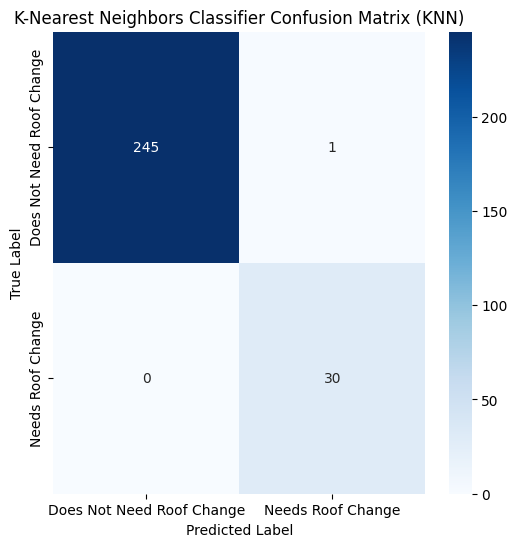

In [110]:
cm_knn = confusion_matrix(y_pred_knn, y_test)
labels = ['Does Not Need Roof Change','Needs Roof Change']

plt.figure(figsize=(6,6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('K-Nearest Neighbors Classifier Confusion Matrix (KNN)')
plt.show()

### Decision Tree Classifier

In [38]:
# To avoid bias towards negative values in the model, class weight is set to 'balanced'

dtc = DecisionTreeClassifier(class_weight='balanced')

# fitting the model to the data and predicting on the scaled test dataset
dtc.fit(X_train_scaled, y_train)
y_pred_dtc = dtc.predict(X_test_scaled)

#### Primary Metrics

In [39]:
print(f'Accuracy: {dtc.score(X_test_scaled, y_test):.2f}')

Accuracy: 0.98


In [40]:
print(classification_report(y_test, y_pred_dtc))

              precision    recall  f1-score   support

       False       1.00      0.98      0.99       245
        True       0.88      0.97      0.92        31

    accuracy                           0.98       276
   macro avg       0.94      0.98      0.96       276
weighted avg       0.98      0.98      0.98       276



#### Confusion Matrix

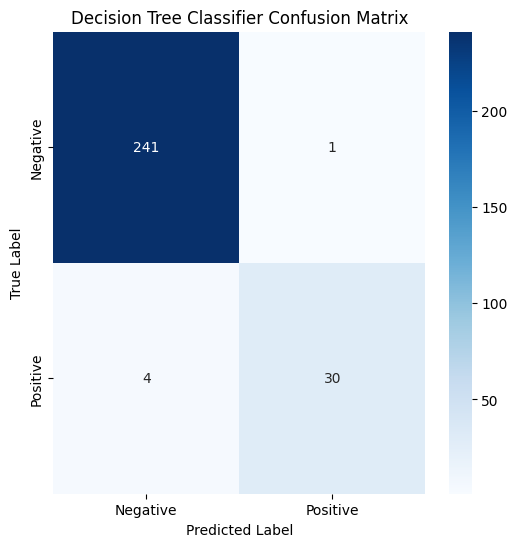

In [41]:
cm_dtc = confusion_matrix(y_pred_dtc, y_test)
labels = ['Negative','Positive']

plt.figure(figsize=(6,6))
sns.heatmap(cm_dtc, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Decision Tree Classifier Confusion Matrix')
plt.show()

### Random Forest Classifier

In [42]:
rfc = RandomForestClassifier(class_weight='balanced')

rfc.fit(X_train_scaled, y_train)
# fitting the model to the data and predicting on the scaled test dataset
rfc.fit(X_train_scaled, y_train)
y_pred_rfc = rfc.predict(X_test_scaled)

#### Primary Metrics 

In [43]:
print(f'Accuracy: {rfc.score(X_test_scaled, y_test):.2f}')

Accuracy: 0.98


In [44]:
print(classification_report(y_test, y_pred_rfc))

              precision    recall  f1-score   support

       False       1.00      0.98      0.99       245
        True       0.88      0.97      0.92        31

    accuracy                           0.98       276
   macro avg       0.94      0.98      0.96       276
weighted avg       0.98      0.98      0.98       276



#### Confusion Matrix

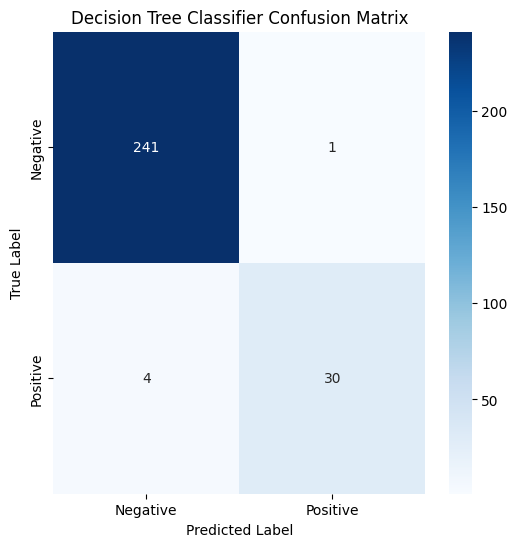

In [45]:
cm_rfc = confusion_matrix(y_pred_rfc, y_test)
labels = ['Negative','Positive']

plt.figure(figsize=(6,6))
sns.heatmap(cm_rfc, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Decision Tree Classifier Confusion Matrix')
plt.show()

### Logistic Regression

In [46]:
lr = LogisticRegression(class_weight='balanced')

# fitting the model to the data and predicting on the scaled test dataset
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

#### Primary Metrics

In [47]:
print(f'Accuracy: {lr.score(X_test_scaled, y_test):.2f}')

Accuracy: 0.97


In [48]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

       False       1.00      0.97      0.98       245
        True       0.79      1.00      0.89        31

    accuracy                           0.97       276
   macro avg       0.90      0.98      0.93       276
weighted avg       0.98      0.97      0.97       276



#### Confusion Matrix

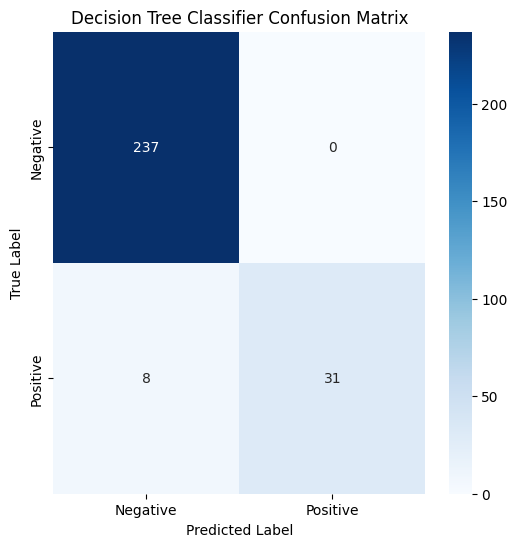

In [49]:
cm_lr = confusion_matrix(y_pred_lr, y_test)
labels = ['Negative','Positive']

plt.figure(figsize=(6,6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Decision Tree Classifier Confusion Matrix')
plt.show()

### ROC & ROC-AUC

ROC = Receiver Operating Characteristic
AUC = Area Under the Curve

AUC = (width of FPR interval) * (height of TPR)

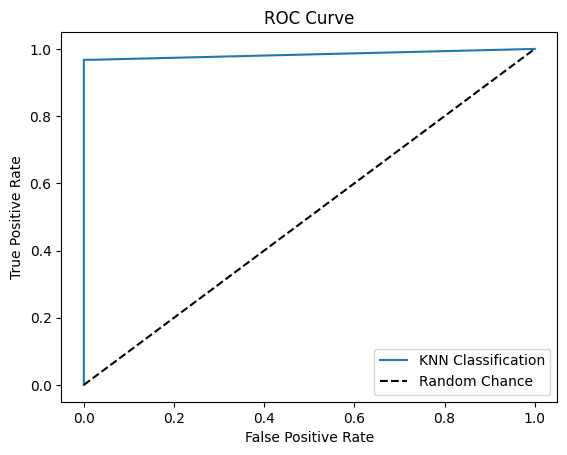

ROC-AUC Score: 0.98


In [118]:
from sklearn.metrics import roc_curve, roc_auc_score

knn.fit(X_train_scaled, y_train)

y_probs = knn.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, threshholds = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr, label='KNN Classification')
plt.plot([0,1], [0,1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

roc_auc = roc_auc_score(y_test, y_probs)
print(f'ROC-AUC Score: {roc_auc:.2f}')